# Take-Home Exam A: Orbital Mechanics

*Submit this notebook with all cells run and all outputs visible. Include written responses in every designated cell. You may use your `myode.py`, numpy, and matplotlib — no other libraries.*

---

## Background

Newton's law of gravity gives the acceleration of a planet orbiting a star at position $(x, y)$:

$$a_x = -\frac{GM\,x}{r^3}, \qquad a_y = -\frac{GM\,y}{r^3}, \qquad r = \sqrt{x^2 + y^2}$$

We use **natural units** where $GM = 1$. In these units a circular orbit at radius $r$ has orbital speed $v_c = 1/\sqrt{r}$ and period $T = 2\pi r^{3/2}$.

Your state vector is $\mathbf{y} = [x,\; v_x,\; y,\; v_y]$, so

$$\dot{\mathbf{y}} = [v_x,\; a_x,\; v_y,\; a_y]$$

The total mechanical energy per unit mass is

$$E = \frac{1}{2}(v_x^2 + v_y^2) - \frac{1}{r}$$

For a bound orbit $E < 0$ and should remain **constant** throughout the simulation.

Furthermore, angular momentum is conserved in this simulation. The equation for angular momentum is

$$\vec{L} = \vec{r} \times \vec{p}$$

In [2]:
%%writefile myode.py
# myode.py — general-purpose ODE solvers
# Functions accept: f (the diffeq function), y (state vector), dt (timestep)

def move_Euler(f, y, dt):
    ydot = f(y)      # call the passed-in diffeq function
    y    = y + ydot * dt        # Euler update (one line)
    return y

def move_RK2(f, y, dt):
    ydot      = f(y)              # derivatives at time t
    y_half    = y + ydot * dt/2   # propagate to midpoint t + dt/2
    ydot_half = f(y_half)         # evaluate diffeq at midpoint
    y         = y + ydot_half * dt  # update to t + dt
    return y

Overwriting myode.py


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import myode

# TODO: implement diffeq for the two-body gravitational problem.
# y = [x, vx, y, vy]
# ydot = [vx, ax, vy, ay]  where ax = -x/r^3, ay = -y/r^3 (GM=1)

def diffeq(y):
    x, vx, yy, vy = y
    r = np.sqrt(x**2 + yy**2)          # distance from origin
    ax = -x/r**3         # x-acceleration
    ay = -yy/r**3         # y-acceleration
    return np.array([vx, ax, vy, ay])

def energy(y):
# compute the total energy of the system (kinetic + potential)
    x, vx, yy, vy = y
    r = np.sqrt(x**2 + yy**2)
    return (0.5)*(vx**2+vy**2)-(1.0/r)

def angular_momentum(y):
    x, vx, yy, vy = y
    return x*vy - yy*vx

## Part 1 — A Circular Orbit

A circular orbit at radius $r = 1$ starts at $(x, y) = (1, 0)$ with velocity $(v_x, v_y) = (0, v_c)$ where $v_c = 1/\sqrt{r}$.

1. Simulate this orbit for two full periods ($t = 0$ to $t = 4\pi$) using RK2 with $dt = 0.01$.
2. Plot the trajectory in the $xy$-plane. Add a marker at the starting point.
3. On a second plot, show $x(t)$ and $y(t)$ vs time.

*Expected result: the trajectory should trace a near-perfect circle.*

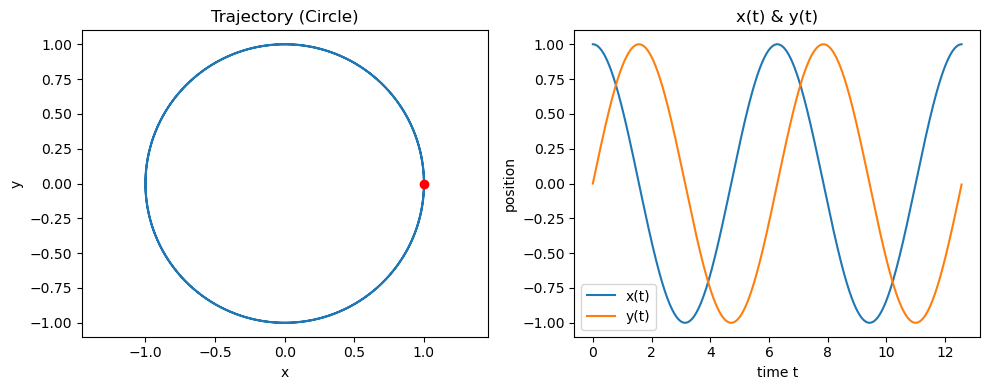

In [4]:
dt = 0.01
T_orbit = 2 * np.pi * 1.0**(3/2)   # period for r=1
t_range = np.arange(0, 2*T_orbit, dt)

# Initial conditions for circular orbit at r=1
r0 = 1.0
vc = 1.0 / np.sqrt(r0)    # circular speed
y0 = np.array([r0, 0.0, 0.0, vc])

# TODO: run the RK2 loop and collect x, y positions and time
xs, ys, ts = [], [], []
y = y0.copy()
for t in t_range:
    xs.append(y[0])
    ys.append(y[2])
    ts.append(t)

    y=myode.move_RK2(diffeq, y, dt)

# TODO: make the two plots described above
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# axes[0]: orbit in xy-plane
axes[0].plot(xs, ys)
axes[0].plot(xs[0], ys[0], "ro", label = 'Starting')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].axis('equal')
axes[0].set_title('Trajectory (Circle)')


# axes[1]: x(t) and y(t) vs time
axes[1].plot(ts, xs, label='x(t)')
axes[1].plot(ts, ys, label='y(t)')
axes[1].set_xlabel('time t')
axes[1].set_ylabel('position')
axes[1].set_title('x(t) & y(t)')
axes[1].legend()
plt.tight_layout()
plt.show()

**Written response (Part 1):** Is the orbit a perfect circle? What would you expect to happen if you increased $dt$ significantly — would the orbit drift inward, outward, or stay the same? Why?

No, the orbit is not a perfect cicle because the RK2 method uses straight line approximations and does not draw a continous curve, and since these lines are so small it look like a perfect circle but in reality since our dt is 0.01 there will be a slight divergence at the start and end points.

When the dt is increased the orbit would drift outward this is because of the straigth line approximation that RK2 does. Since the dt increases the length of each line would also increase, so it overshoots and travels along this line for a longer dt, making the orbit drift outward.

## Part 2 — Euler vs. RK2

Repeat the circular orbit simulation using **both** Euler's method and RK2 with the same (larger) timestep $dt = 0.2$. Run for 5 full periods.

1. Plot both trajectories on the same $xy$-plane graph.
2. What qualitative difference do you observe?

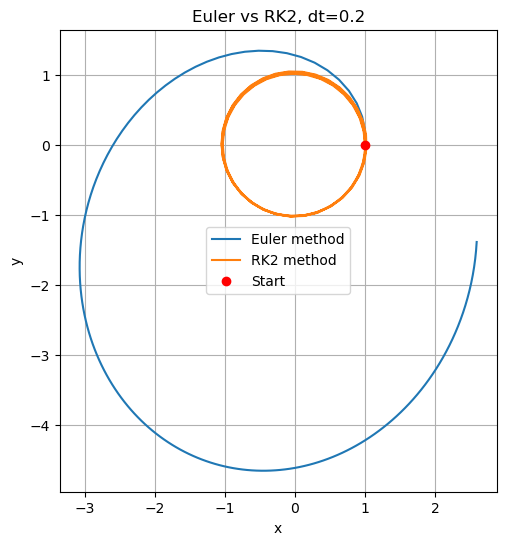

In [5]:
dt = 0.2
T_orbit = 2 * np.pi
t_range = np.arange(0, 5*T_orbit, dt)
y0 = np.array([1.0, 0.0, 0.0, 1.0])

# TODO: run both Euler and RK2 loops, collect x and y
# xs_euler, ys_euler = ...
xs_euler, ys_euler = [], []
y_euler = y0.copy()
for t in t_range:
    xs_euler.append(y_euler[0])
    ys_euler.append(y_euler[2])
    y_euler = myode.move_Euler(diffeq, y_euler, dt)


# xs_rk2,   ys_rk2   = ...
xs_rk2, ys_rk2 = [], []
y_rk2 = y0.copy()
for t in t_range:
    xs_rk2.append(y_rk2[0])
    ys_rk2.append(y_rk2[2])
    y_rk2=myode.move_RK2(diffeq, y_rk2, dt)


fig, ax = plt.subplots(figsize=(6, 6))
# TODO: plot both orbits and add a legend
ax.set_aspect('equal')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Euler vs RK2, dt=0.2')

ax.plot(xs_euler, ys_euler, label='Euler method')
ax.plot(xs_rk2, ys_rk2, label = 'RK2 method')
ax.plot(y0[0], y0[2], 'ro', label='Start')
ax.legend()
ax.grid(True)

plt.show()

**Written response (Part 2):** Describe what you observe in each orbit. Why does one method fail while the other succeeds? Connect your answer to the concept of *local truncation error*.

The RK2 method gives a graph that represent a circle while the Euler method does not form a circle but rather spiral's outwards away from the starting point.

This occurs due to the Euler being a first order method while the RK2 is a second order method. According to the local truncation error the global error of the euler function is O(h**1) while the global error for RK2 is O(h\**2). The dt is too large for euler which makes the object overshoot from the desired path. While RK2 the dt is squared making it account for even the smallest changes and can turn more efficiently.

## Part 3 — Energy and Angular Momentum Conservation

Using the same $dt = 0.2$ and 5 orbital periods, track the total energy $E(t)$ and angular momentum $L(t)$ for both Euler and RK2.

1. Plot $E(t)$ vs time for both methods on the same graph. On a separate graph, do the same for $L(t)$ for both methods.
2. Compute the *fractional* energy error at the end: $(E_{\rm final} - E_0) / |E_0|$. Do the same for the fractional angular momentum error.

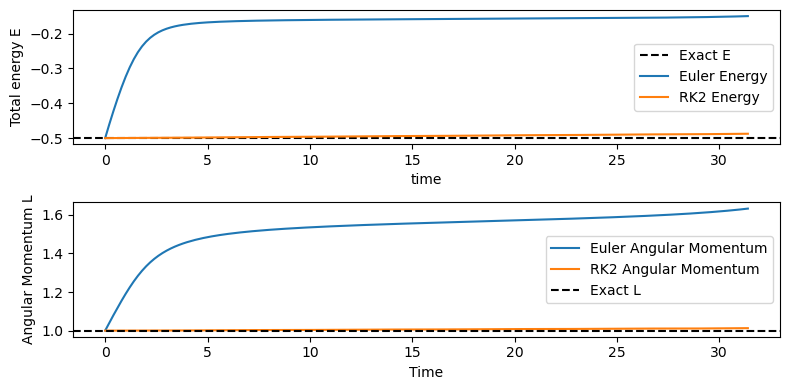

Fractional Energy Error (Euler): 0.7010
Fractional Energy Error (RK2):   0.0251
---------------------------------------------
Fractional Energy Error (Euler): 0.6326
Fractional Energy Error (RK2):   0.0128


In [9]:
dt = 0.2
t_range = np.arange(0, 5*2*np.pi, dt)
y0 = np.array([1.0, 0.0, 0.0, 1.0])
E0 = energy(y0)
L0 = angular_momentum(y0)

# TODO: run both methods, compute energy at each step
# E_euler = []
E_euler, L_euler = [], []
y_euler = y0.copy()
for t in t_range:
    E_euler.append(energy(y_euler))
    L_euler.append(angular_momentum(y_euler))
    y_euler = myode.move_Euler(diffeq, y_euler, dt)

    
# E_rk2   = []
E_rk2, L_rk2 = [], []
y_rk2 = y0.copy()
for t in t_range:
    E_rk2.append(energy(y_rk2))
    L_rk2.append(angular_momentum(y_rk2))
    y_rk2 = myode.move_RK2(diffeq, y_rk2, dt)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 4))
# TODO: plot E_euler and E_rk2 vs time
ax1.axhline(E0, color='k', linestyle='--', label='Exact E')
ax1.set_xlabel('time'); ax1.set_ylabel('Total energy E')
ax1.plot(t_range, E_euler, label = 'Euler Energy')
ax1.plot(t_range, E_rk2, label = 'RK2 Energy')


ax2.plot(t_range, L_euler, label = 'Euler Angular Momentum')
ax2.plot(t_range, L_rk2, label = 'RK2 Angular Momentum')
ax2.axhline(L0, color='k', linestyle='--', label='Exact L')
ax2.set_xlabel('Time')
ax2.set_ylabel('Angular Momentum L')
ax2.legend()


ax1.legend(); 


plt.tight_layout(); plt.show()

# TODO: print fractional energy error for each method
frac_E_euler = (E_euler[-1]-E0)/np.abs(E0)
frac_E_rk2 = (E_rk2[-1]-E0)/np.abs(E0)

print(f"Fractional Energy Error (Euler): {frac_E_euler:.4f}")
print(f"Fractional Energy Error (RK2):   {frac_E_rk2:.4f}")

# TODO: repeat for angular momentum L and print fractional errors
frac_L_euler = (L_euler[-1]-L0)/np.abs(L0)
frac_L_rk2 = (L_rk2[-1]-L0)/np.abs(L0)
print('-'*45)
print(f"Fractional Energy Error (Euler): {frac_L_euler:.4f}")
print(f"Fractional Energy Error (RK2):   {frac_L_rk2:.4f}")

**Written response (Part 3):** For which method does energy drift, and in which direction? What does this tell you physically about where the planet would end up after many orbits? Is energy *supposed* to be conserved for this system? What about angular momentum?

The Energy drifts in the Euler method towards the positive direction. Physically the planet would end up escaping the star's gravity. Since, the planet is bound when the E<0, after many orbit the planet would have an E>0 at which it is no longer bound to the star anymore.

Yes, the total energy is supposed to be conserved for this system and same goes for angular momentum. The reason these changes occur is due to the errors in the final values that these methods provide.

## Part 4 — Kepler's Third Law

Kepler's third law states that $T^2 \propto r^3$ for circular orbits. In our units ($GM = 1$), the exact relation is $T = 2\pi r^{3/2}$.

1. Simulate circular orbits at four radii: $r = 0.5,\; 1.0,\; 2.0,\; 4.0$.
2. For each, measure the period numerically by finding when the planet first returns to its starting $x$-position with positive $v_y$ (i.e., completes one full revolution).
3. Make a log-log plot of measured $T$ vs $r$. Add the theoretical line.
4. From the slope of the log-log plot, extract the exponent $n$ in $T \propto r^n$.

r=0.5: T_measured=2.2214, T_theory=2.2214
r=1.0: T_measured=6.2832, T_theory=6.2832
r=2.0: T_measured=17.7715, T_theory=17.7715
r=4.0: T_measured=50.2655, T_theory=50.2655


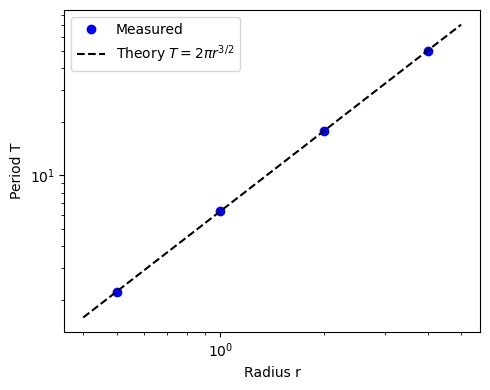

Measured exponent: 1.500  (expected: 1.5)


In [7]:
radii = [0.5, 1.0, 2.0, 4.0]
measured_periods = []

for r0 in radii:
    vc = 1.0 / np.sqrt(r0)
    y0 = np.array([r0, 0.0, 0.0, vc])
    T_theory = 2 * np.pi * r0**(3/2)
    dt = T_theory / 500    # ~500 steps per orbit
    t_range = np.arange(0, 2*T_theory, dt)

    # TODO: run RK2 and find the period
    y = y0.copy()
    left_start = False
    period = None

    for t in t_range:
        y = myode.move_RK2(diffeq, y, dt)

        if y[0] < r0:
            left_start = True

        if left_start and y[0] >= r0:
            period = t+dt
            break
    
    # Hint: the orbit completes when x returns to r0 from below (x crosses r0 upward)
    # You can detect this by checking when x >= r0 after spending time at x < r0
    measured_periods.append(period)
    print(f'r={r0}: T_measured={period:.4f}, T_theory={T_theory:.4f}')

# Log-log plot
r_arr = np.array(radii)
T_arr = np.array(measured_periods)
r_fine = np.linspace(0.4, 5, 100)

fig, ax = plt.subplots(figsize=(5, 4))
ax.loglog(r_arr, T_arr, 'bo', label='Measured')
ax.loglog(r_fine, 2*np.pi*r_fine**(3/2), 'k--', label='Theory $T=2\pi r^{3/2}$')
ax.set_xlabel('Radius r'); ax.set_ylabel('Period T')
ax.legend(); plt.tight_layout(); plt.show()

# Fit exponent from log-log slope
# slope = np.polyfit(np.log(r_arr), np.log(T_arr), 1)[0]
# print(f'Measured exponent: {slope:.3f}  (expected: 1.5)')
slope = np.polyfit(np.log(r_arr), np.log(T_arr), 1)[0]
print(f'Measured exponent: {slope:.3f}  (expected: 1.5)')

**Written response (Part 4):** Report your measured exponent. How well does it match the theoretical value of $3/2$? If there is a discrepancy, suggest one numerical reason why.

The measured exponent is 1.5. It matches exactly to the value of 3/2 and I found no discrepancy. There might have been discrepancy if the dt was larger but since 500 steps were taken the value found was exact.

## Part 5 — Open-Ended Exploration

**A:** Simulate an *elliptical* orbit (e.g. start at $(1, 0)$ with $v_y = 0.8$, which is less than the circular speed). Track energy and angular momentum over time. Are they conserved? Does the orbit precess (does the point of closest approach drift over time)?

**B:** Add a second planet (same mass as the first, starting on the opposite side of the star). The star remains fixed. Each planet feels gravity from the star only (ignore planet-planet gravity for simplicity). Run the system for 10 orbits. Now add planet-planet gravity and observe how the orbits change.

**C:** Remove the fixed star. Place two equal-mass objects at $(-1, 0)$ and $(1, 0)$ with equal and opposite initial velocities. This is the equal-mass binary star problem. Find initial velocities that produce a stable circular orbit. What is the orbital period?

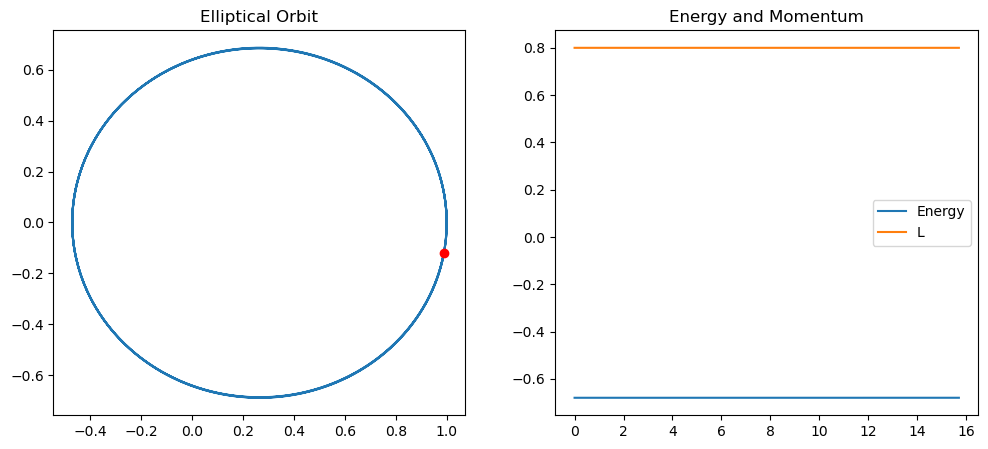

In [17]:
# Part 5 A
y_ellip = np.array([1.0, 0.0, 0.0, 0.8])
dt = 0.01
t_ellip = np.arange(0,5*np.pi, dt)

xs, ys = [], []
Es, Ls = [], []

for t in t_ellip:
    xs.append(y_ellip[0]); ys.append(y_ellip[2])
    Es.append(energy(y_ellip))
    Ls.append(angular_momentum(y_ellip))
    y_ellip = myode.move_RK2(diffeq, y_ellip, dt)

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,5))
ax1.plot(xs, ys)
ax1.set_aspect('equal')
ax1.set_title("Elliptical Orbit")
ax1.plot(y_ellip[0], y_ellip[2], 'ro', label='Start')
ax2.plot(t_ellip, Es, label='Energy')
ax2.plot(t_ellip, Ls, label='L')
ax2.set_title("Energy and Momentum")
ax2.legend()
plt.show()

Part 5A:
Yes both Energy and angular momentum are conserved over time.
No, the orbit does not process for this dt but if a larger dt were used then it would.

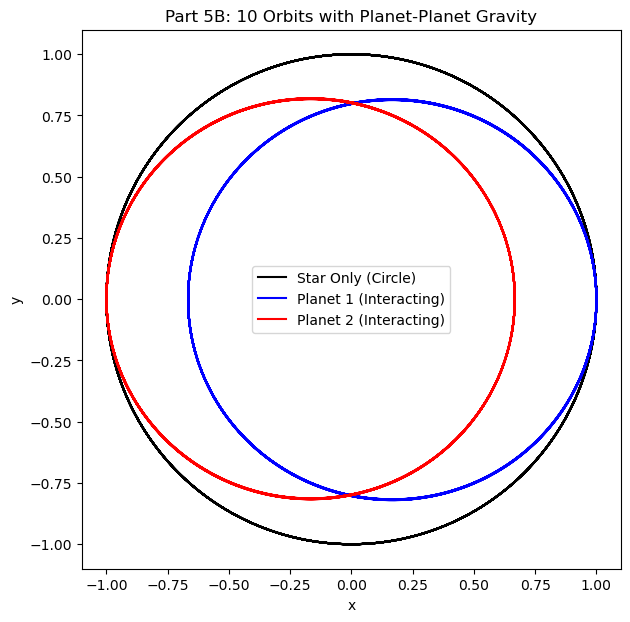

In [15]:
#Part 5 B
def diffeq_2planet_no_int(y):
    x1, vx1, y1, vy1, x2, vx2, y2, vy2 = y
    r1 = (x1**2 + y1**2)**0.5
    ax1 = -x1 / r1**3
    ay1 = -y1 / r1**3

    r2 = (x2**2 + y2**2)**0.5
    ax2 = -x2 / r2**3
    ay2 = -y2 / r2**3

    return np.array([vx1, ax1, vy1, ay1, vx2, ax2, vy2, ay2])

def diffeq_2planet_with_int(y):
    x1, vx1, y1, vy1, x2, vx2, y2, vy2 = y
    m_p = 1

    r1 = (x1**2 + y1**2)**0.5
    r2 = (x2**2 + y2**2)**0.5

    dx = x2 - x1
    dy = y2 - y1
    r12 = (dx**2 + dy**2)**0.5

    ax1 = (-x1 / r1**3) + (m_p * dx / r12**3)
    ay1 = (-y1 / r1**3) + (m_p * dy / r12**3)

    ax2 = (-x2 / r2**3) - (m_p * dx / r12**3)
    ay2 = (-y2 / r2**3) - (m_p * dy / r12**3)

    return np.array([vx1, ax1, vy1, ay1, vx2, ax2, vy2, ay2])
    
dt = 0.01
t_range = np.arange(0, 10 * 2 * np.pi, dt)
y0 = np.array([1.0, 0.0, 0.0, 1.0, -1.0, 0.0, 0.0, -1.0])

#no interaction
y_no = y0.copy()
p1x_no, p1y_no = [], []
for t in t_range:
    p1x_no.append(y_no[0]); p1y_no.append(y_no[2])
    y_no = myode.move_RK2(diffeq_2planet_no_int, y_no, dt)


#with interaction
y_int = y0.copy()
p1x_int, p1y_int = [], []
p2x_int, p2y_int = [], []
for t in t_range:
    p1x_int.append(y_int[0]); p1y_int.append(y_int[2])
    p2x_int.append(y_int[4]); p2y_int.append(y_int[6])
    y_int = myode.move_RK2(diffeq_2planet_with_int, y_int, dt)

fig, ax = plt.subplots(figsize=(7, 7))

# Plot Star-only path as a reference (dashed)
ax.plot(p1x_no, p1y_no, 'k' , label="Star Only (Circle)")

# Plot Interacting planets
ax.plot(p1x_int, p1y_int, 'b-', label="Planet 1 (Interacting)")
ax.plot(p2x_int, p2y_int, 'r-', label="Planet 2 (Interacting)")

ax.set_aspect('equal')
ax.set_title("Part 5B: 10 Orbits with Planet-Planet Gravity")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend()
plt.show()


The orbits of the planets with gravity interacting each other are smaller than non interaction and also the orbits are shifted from the center.

In [16]:
#Part C
def diffeq_binary_star(y):

    x1, vx1, y1, vy1, x2, vx2, y2, vy2 = y
    
    dx = x2 - x1
    dy = y2 - y1
    r12 = (dx**2 + dy**2)**0.5
    
    ax1 = dx / r12**3
    ay1 = dy / r12**3
    
    ax2 = -dx / r12**3
    ay2 = -dy / r12**3
    
    return np.array([vx1, ax1, vy1, ay1, vx2, ax2, vy2, ay2])



r_start = 1.0
dist_total = 2.0
GM = 1.0
v_stable = np.sqrt(GM * r_start / (dist_total**2))
print(f"Calculated Stable Velocity: {v_stable}")

y_bin = np.array([-1.0, 0.0, 0.0, -v_stable, 1.0, 0.0, 0.0, v_stable])
dt = 0.001
t = 0
period_found = False

while not period_found:
    y_old = y_bin.copy()
    y_bin = myode.move_RK2(diffeq_binary_star, y_bin, dt)
    t += dt
    if y_old[2] < 0 and y_bin[2] >= 0:
        period_found = True
        measured_T = t
        print(f"Measured Orbital Period: {measured_T:.4f}")

Calculated Stable Velocity: 0.5
Measured Orbital Period: 6.2840
